|<h2>Course:</h2>|<h1><a href="https://derivingsystems.com/course.html" target="_blank">Build your own vLLM: inference engines from the memory system up</a></h1>|
|-|:-:|
|<h2>Part 6:</h2>|<h1>The Server<h1>|
|<h2>Section:</h2>|<h1>The async engine<h1>|
|<h2>Lecture:</h2>|<h1><b>One loop, two clocks, and what happens when a client hangs up<b></h1>|

<br>

<h5><b>Course repo:</b> <a href="https://github.com/Venugopalan2610/vllm-from-scratch" target="_blank">github.com/Venugopalan2610/vllm-from-scratch</a></h5>
<h5><b>The derivations:</b> <a href="https://derivingsystems.com" target="_blank">derivingsystems.com</a></h5>
<i>The notebooks build the intuition. The ladder in app/ makes you build the thing.</i>

In [1]:
import asyncio
import time
import numpy as np
import matplotlib.pyplot as plt
import matplotlib_inline.backend_inline
matplotlib_inline.backend_inline.set_matplotlib_formats('svg')

STEP_S = 0.010        # one engine step, 10 ms
NUM_CLIENTS = 8       # clients at the same time
TOKENS = 20           # tokens for each client

# The loop that must never block

All of the work until now was one process that did one thing. A server does
two things at the same time: HTTP and a GPU. Neither one can wait for the
other.

Make the obvious mistake, and each request in flight pays for all of the
others.

In [2]:
async def timed_client(next_token, tokens, start):
  """Wait for `tokens` tokens.
  -> (time to the first token, time to the last token), from start."""
  first = None
  for _ in range(tokens):
    await next_token()
    if first is None:
      first = time.perf_counter() - start
  return first, time.perf_counter() - start

async def run_blocking(num_clients=NUM_CLIENTS, tokens=TOKENS):
  """The model runs inside the event loop. Nothing else can run."""
  start = time.perf_counter()
  async def blocking_step():
    time.sleep(STEP_S)                      # a blocking call
  latencies = await asyncio.gather(
      *[timed_client(blocking_step, tokens, start) for _ in range(num_clients)])
  return latencies, time.perf_counter() - start

async def run_threaded(num_clients=NUM_CLIENTS, tokens=TOKENS):
  """The model runs in a thread pool. The event loop stays responsive."""
  loop = asyncio.get_running_loop()
  start = time.perf_counter()
  def threaded_step():
    return loop.run_in_executor(None, time.sleep, STEP_S)
  latencies = await asyncio.gather(
      *[timed_client(threaded_step, tokens, start) for _ in range(num_clients)])
  return latencies, time.perf_counter() - start

async def run_engine(num_clients=NUM_CLIENTS, tokens=TOKENS):
  """ONE loop steps the model. Each client reads tokens from its own queue."""
  streams = [asyncio.Queue() for _ in range(num_clients)]
  start = time.perf_counter()
  async def engine():
    for step in range(tokens):
      await asyncio.sleep(STEP_S)           # one step serves ALL clients
      for stream in streams:
        stream.put_nowait(step)
  _, *latencies = await asyncio.gather(
      engine(), *[timed_client(stream.get, tokens, start) for stream in streams])
  return latencies, time.perf_counter() - start

In [3]:
# A notebook runs an event loop already. So use `await` at the top level.
# asyncio.run() does not work inside a running loop.
print(f"{'design':>10} {'wall':>7} {'TTFT p50':>10} {'TTFT p99':>10} {'last done':>10}")
results = {}
for name, run in (('blocking', run_blocking), ('threaded', run_threaded),
                  ('engine', run_engine)):
  latencies, wall = await run()
  ttfts = sorted(first for first, _ in latencies)
  last_done = max(done for _, done in latencies)
  results[name] = (wall, ttfts, last_done)
  print(f'{name:>10} {wall:>6.2f}s {ttfts[len(ttfts)//2]:>9.3f}s '
        f'{ttfts[-1]:>9.3f}s {last_done:>9.2f}s')

    design    wall   TTFT p50   TTFT p99  last done


  blocking   1.63s     0.823s     1.435s      1.63s


  threaded   0.22s     0.014s     0.016s      0.22s


    engine   0.21s     0.010s     0.010s      0.21s


### Read the first row

Eight clients, twenty tokens each, ten milliseconds for each step. The work
needs 1.6 seconds if you do it one client at a time. It needs 0.2 seconds if
you do it correctly.

The blocking design does one client at a time. `time.sleep`, or a synchronous
`model(x)`, does not yield. `asyncio.gather` looks concurrent, and it is not.
The first coroutine that touches the model owns the process until it stops.

The damage falls on **time to first token**. That is what a user sees while
they watch a cursor.

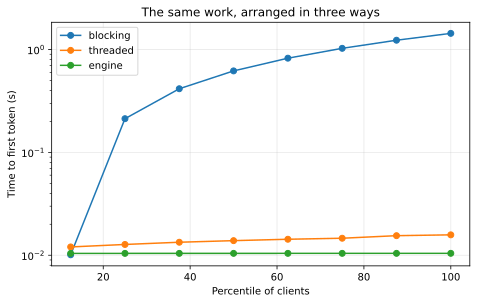

the blocking p99 TTFT is 138x that of the engine loop


In [4]:
plt.figure(figsize=(7.5,4.4))
for name, (wall, ttfts, last_done) in results.items():
  percentiles = np.arange(1, len(ttfts)+1) / len(ttfts) * 100
  plt.plot(percentiles, ttfts, 'o-', label=name)
plt.yscale('log')
plt.xlabel('Percentile of clients')
plt.ylabel('Time to first token (s)')
plt.title('The same work, arranged in three ways')
plt.legend()
plt.grid(alpha=.3)
plt.show()
blocking_p99 = results['blocking'][1][-1]
engine_p99 = results['engine'][1][-1]
print(f'the blocking p99 TTFT is {blocking_p99/engine_p99:.0f}x that of the engine loop')

### The threaded version looks correct here, and it will not stay correct

A thread pool keeps the event loop responsive. In this simulation it is as
fast as the engine loop. `time.sleep` releases the interpreter lock, so eight
threads really do sleep at the same time.

A GPU does not work like that. There is one device. Eight threads that each
run a forward pass do **not** run at the same time. They serialise on the GPU.
Worse, each one reads the whole model from HBM to make its single token.

That is the arithmetic from Part 1 again. Threads correct the responsiveness.
Only a batch corrects the throughput.

To make a batch you need one thing that an engine loop has. A thread pool does
not have it: **one place that sees all of the in-flight requests at the same
time**.

So the shape must be this:

- one loop calls `step()` forever, over the sequences that run now
- requests arrive from HTTP and go into a queue
- tokens leave through one queue for each request
- nothing blocks in either direction

# What happens when a client hangs up

A user closes the tab. The request still runs. It still holds KV blocks. It
still costs a slot.

This case is not rare. A browser does it on every navigation. It is the
difference between a server that survives a day of real traffic and a server
that fills up.

In [5]:
async def with_cancellation(num_clients=6, tokens=30, quit_after=5):
  streams = {client_id: asyncio.Queue() for client_id in range(num_clients)}
  live = set(range(num_clients))
  freed = []                      # (client, step) for each client that hung up
  async def engine():
    for step in range(tokens):
      await asyncio.sleep(STEP_S)
      for client_id in list(live):
        streams[client_id].put_nowait(step)
  async def client(client_id):
    step = 0
    try:
      for step in range(tokens):
        await streams[client_id].get()
        if client_id % 2 == 0 and step == quit_after:
          raise asyncio.CancelledError            # the tab closes
    except asyncio.CancelledError:
      live.discard(client_id)                     # FREE THE BLOCKS
      freed.append((client_id, step))
      raise
  clients = [asyncio.create_task(client(client_id)) for client_id in range(num_clients)]
  await asyncio.gather(engine(), *clients, return_exceptions=True)
  return freed, live

freed, live = await with_cancellation()
print(f'clients that hung up: {[client_id for client_id, _ in freed]}')
print(f'still running:        {sorted(live)}')
print(f'\nslots freed at step {freed[0][1]}, not at step 29')

clients that hung up: [0, 2, 4]
still running:        [1, 3, 5]

slots freed at step 5, not at step 29


The `finally` that removes the request from the running set is the whole
feature. Without it the sequence keeps generating into a queue nobody reads,
until it hits its length limit, holding blocks the entire time.

Stage 15 has a check for exactly this: disconnect a client and assert the KV
blocks come back.

    ./vc guide 15